In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score,precision_score,recall_score,f1_score


In [3]:
data = {"age":[25,30,28,35,24,40,27,32],
        "Monthly_Income":[30000,50000,45000,70000,28000,90000,42000,60000],
        "Years_At_Company":[1,5,3,7,1,10,2,6],
        "Job_Role":["Developer","Tester","HR","Manager","Support","Manager","Developer","Tester"],
        "Attrition":["Yes","No","No","No","Yes","No","Yes","No"]}

In [4]:
df = pd.DataFrame(data)
df.head()

,age,Monthly_Income,Years_At_Company,Job_Role,Attrition
0,25,30000,1,Developer,Yes
1,30,50000,5,Tester,No
2,28,45000,3,HR,No
3,35,70000,7,Manager,No
4,24,28000,1,Support,Yes


In [5]:
le = LabelEncoder()
df['Job_Role'] = le.fit_transform(df['Job_Role'])
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})


In [6]:
df["Job_Role"]

,Job_Role
0,0
1,4
2,1
3,2
4,3
5,2
6,0
7,4


In [7]:
x = df.drop('Attrition', axis=1)
y = df['Attrition']

In [8]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [9]:
scaler = MinMaxScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [10]:
x_train_scaled

array([[0.09090909, 0.04761905, 0.        , 0.        ],
       [0.72727273, 0.76190476, 0.83333333, 1.        ],
       [0.36363636, 0.4047619 , 0.33333333, 0.25      ],
       [0.        , 0.        , 0.        , 0.75      ],
       [1.        , 1.        , 1.        , 0.5       ],
       [0.27272727, 0.33333333, 0.16666667, 0.        ]])

In [11]:
x_test_scaled

array([[0.54545455, 0.52380952, 0.66666667, 1.        ],
       [1.45454545, 1.47619048, 1.5       , 0.5       ]])

In [12]:
model = RandomForestClassifier(n_estimators=200, random_state=42,)
model.fit(x_train_scaled, y_train)
y_pred = model.predict(x_test_scaled)


In [13]:
y_pred

array([0, 0])

In [14]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


In [15]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



In [16]:
new_data = {"age":[29],"Monthly_Income":[55000],"Years_At_Company":[4],"Job_Role":[le.transform(['Developer'])[0]]}

In [17]:
new_df = pd.DataFrame(new_data)

In [18]:
scaler = MinMaxScaler()
new_data_scaled = scaler.fit_transform(new_df)

In [19]:
prediction = model.predict(new_data_scaled)

In [20]:
prediction 

array([1])

In [21]:
importamce = model.feature_importances_
feature_names = x.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importamce})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)



In [22]:
feature_importance_df

,Feature,Importance
1,Monthly_Income,0.319797
0,age,0.314721
2,Years_At_Company,0.289340
3,Job_Role,0.076142


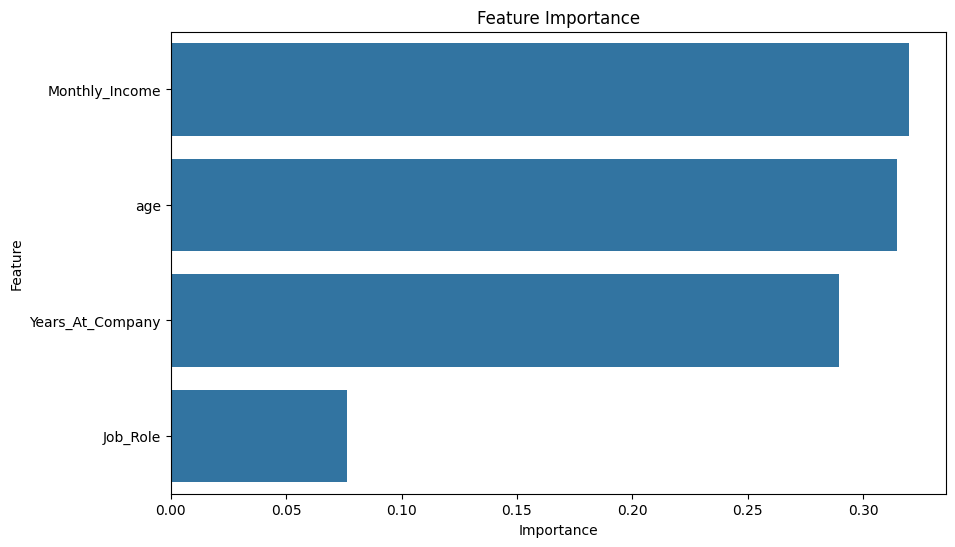

In [23]:
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()